In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as an
import sys
sys.path.append('/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/')

from inflapy.immunoFunc import *

In [2]:
path = "/nfs/team205/bh14/Datasets/RawData/raw_and_AnnData/annDataModified/Kong_et_al_2023_modified.h5ad"

s_path = "/nfs/team205/bh14/Datasets/Remapped/raw_adata/ummapped/"

In [3]:
#os.listdir(path)

#### Kong dataset

In [4]:
adata = sc.read_h5ad(path)

In [5]:
adata.var_names

Index(['AL627309.1', 'AP006222.2', 'RP4-669L17.10', 'RP11-206L10.3',
       'RP11-206L10.2', 'RP11-206L10.9', 'FAM87B', 'LINC00115', 'FAM41C',
       'RP11-54O7.3',
       ...
       'RP11-236J17.6', 'AP000479.1', 'GLYAT', 'LACRT', 'LINC00555',
       'LINC00676', 'RP11-739N10.1', 'CTB-60B18.18', 'CTD-2616J11.3',
       'AC006272.2'],
      dtype='object', length=27830)

In [6]:
adata

AnnData object with n_obs × n_vars = 353581 × 27830
    obs: 'Site', 'donor_id', 'disease', 'dataset_id', 'tissue'

In [7]:
adata.obs.tissue.value_counts()

ileum    201072
colon    152509
Name: tissue, dtype: int64

In [8]:
adata.obs


,Site,donor_id,disease,dataset_id,tissue
N105446_L-TGTCCTGGTCCCGTGA,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
N105446_L-CCTACGTGTGAATGTA,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
N105446_L-TATCCTAGTGACAGGT,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
N105446_L-CTGCATCAGCACCTGC,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
N105446_L-GGTGATTAGAACCCGA,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
...,...,...,...,...,...
N119540_L2-CACTGGGAGCTGACCC,TI,N119540_L2,Uninflam_CD,Kong_et_al_2023,ileum
N119540_L2-CGAGGCTTCTCACTCG,TI,N119540_L2,Uninflam_CD,Kong_et_al_2023,ileum
N119540_L2-CTCAAGATCTACGCGG,TI,N119540_L2,Uninflam_CD,Kong_et_al_2023,ileum
N119540_L2-TATTCCATCGCCTAGG,TI,N119540_L2,Uninflam_CD,Kong_et_al_2023,ileum


In [9]:
#adata.obs["cell_source"] = adata.obs["tissue"].str.replace("_HC", "").str.replace("_BD", "")

In [10]:
#adata.obs["tissue"] = np.repeat("Blood", adata.n_obs)

In [11]:
adata.obs

,Site,donor_id,disease,dataset_id,tissue
N105446_L-TGTCCTGGTCCCGTGA,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
N105446_L-CCTACGTGTGAATGTA,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
N105446_L-TATCCTAGTGACAGGT,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
N105446_L-CTGCATCAGCACCTGC,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
N105446_L-GGTGATTAGAACCCGA,CO,N105446_L,Uninflam_CD,Kong_et_al_2023,colon
...,...,...,...,...,...
N119540_L2-CACTGGGAGCTGACCC,TI,N119540_L2,Uninflam_CD,Kong_et_al_2023,ileum
N119540_L2-CGAGGCTTCTCACTCG,TI,N119540_L2,Uninflam_CD,Kong_et_al_2023,ileum
N119540_L2-CTCAAGATCTACGCGG,TI,N119540_L2,Uninflam_CD,Kong_et_al_2023,ileum
N119540_L2-TATTCCATCGCCTAGG,TI,N119540_L2,Uninflam_CD,Kong_et_al_2023,ileum


In [12]:
gc.collect()

68

In [13]:
adata.var_names

Index(['AL627309.1', 'AP006222.2', 'RP4-669L17.10', 'RP11-206L10.3',
       'RP11-206L10.2', 'RP11-206L10.9', 'FAM87B', 'LINC00115', 'FAM41C',
       'RP11-54O7.3',
       ...
       'RP11-236J17.6', 'AP000479.1', 'GLYAT', 'LACRT', 'LINC00555',
       'LINC00676', 'RP11-739N10.1', 'CTB-60B18.18', 'CTD-2616J11.3',
       'AC006272.2'],
      dtype='object', length=27830)

#####################################################
###                      Kong_CD_2023                 ###
######################################################
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.47
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 50.2%
Overall doublet rate:
	Expected   = 7.6%
	Estimated  = 0.9%
Elapsed time: 2254.4 seconds
Pass            215808
Low_nFeature    136212
Doublet           1561
Name: QC, dtype: int64
Plot of metadata only for cells that pass tentative QC:  



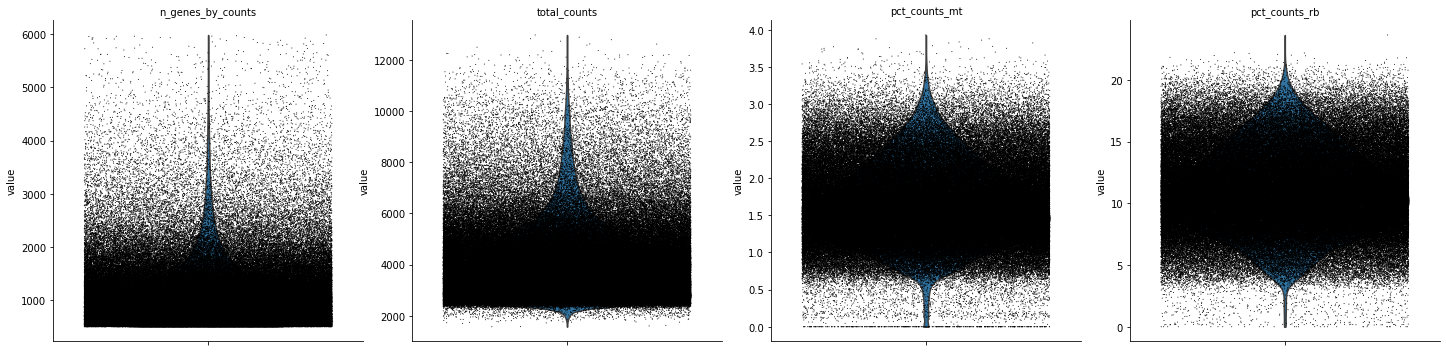

In [14]:
adataQc(adata=adata, path=s_path+"Tissue/QC_Doublet/", file="Kong_CD_2023")

In [15]:
adata.obs.donor_id.value_counts()

N104689_N     14300
I104689_N1     8027
N51_LP_A       6915
I130084_L      6660
N128400_L      6539
              ...  
N8_Epi_A         13
H102141_E         7
H157844_E         6
I191305_E2        1
N8_Epi_B          1
Name: donor_id, Length: 224, dtype: int64